# Simulate beta posterior

You are given a list of ten coin tosses, called tosses, in which 1 stands for heads, 0 for tails, and we define heads as a "success". To simulate the posterior probability of tossing heads, you will use a beta prior

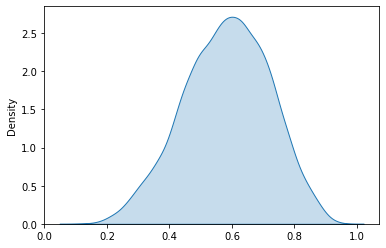

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
tosses = [1, 0, 0, 1, 0, 1, 1, 1, 0, 1]
# Set prior parameters and calculate number of successes
beta_prior_a = 1
beta_prior_b = 1
num_successes = np.sum(tosses)

# Generate 10000 posterior draws
posterior_draws = np.random.beta(
  num_successes + beta_prior_a, 
  len(tosses) - num_successes + beta_prior_b, 
  10000)  

# Plot density of posterior_draws
sns.kdeplot(posterior_draws, shade=True)
plt.show()

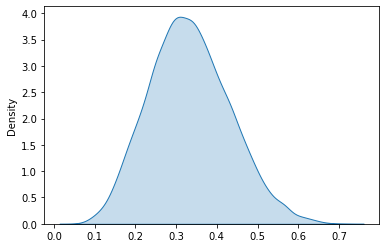

In [2]:
# Set prior parameters and calculate number of successes
beta_prior_a = 1
beta_prior_b = 10
num_successes = np.sum(tosses)

# Generate 10000 posterior draws
posterior_draws = np.random.beta(
  num_successes + beta_prior_a, 
  len(tosses)-num_successes + beta_prior_b, 
  10000)  

# Plot density of posterior_draws
sns.kdeplot(posterior_draws, shade=True)
plt.show()

# Posterior click rates

After a successful career episode at the Department for Health, you switch to marketing. Your new company has just run two pilot advertising campaigns: one for sneakers, and one for clothes. Your job is to find out which one was more effective as measured by the click-through rate and should be rolled out to a larger audience.

You decide to run A/B testing, modeling the data using the binomial likelihood. You found out that a typical click-through rate for the previous ads has been around 15% recently, with results varying between 5% and 30%. Based on this, you conclude that beta(10,50)
 would be a good prior for the click-through rate.

In [3]:
def simulate_beta_posterior(trials, beta_prior_a, beta_prior_b):
    num_successes = np.sum(trials)
    return np.random.beta(num_successes + beta_prior_a, len(trials) - num_successes + beta_prior_b, 10000)

In [4]:
import pandas as pd
ads = pd.read_csv("dataset/ads.csv")
ads.head()

,user_id,product,site_version,time,banner_clicked
0,f500b9f27ac611426935de6f7a52b71f,clothes,desktop,2019-01-28 16:47:08,0
1,cb4347c030a063c63a555a354984562f,sneakers,mobile,2019-03-31 17:34:59,0
2,89cec38a654319548af585f4c1c76b51,clothes,mobile,2019-02-06 09:22:50,0
3,1d4ea406d45686bdbb49476576a1a985,sneakers,mobile,2019-05-23 08:07:07,0
4,d14b9468a1f9a405fa801a64920367fe,clothes,mobile,2019-01-28 08:16:37,0


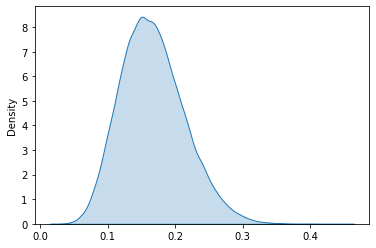

In [5]:
# Generate prior draws
prior_draws = np.random.beta(10, 50, size=100000) 

# Plot the prior
sns.kdeplot(prior_draws, shade=True, label="prior")
plt.show()

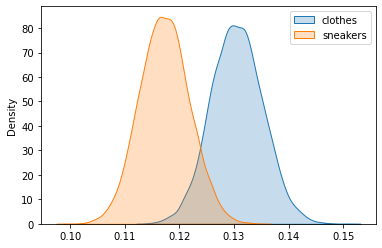

In [6]:

# Extract the banner_clicked column for each product
clothes_clicked = ads.loc[ads["product"] == "clothes"]["banner_clicked"]
sneakers_clicked = ads.loc[ads["product"] == "sneakers"]["banner_clicked"]


# Simulate posterior draws for each product
clothes_posterior = simulate_beta_posterior(clothes_clicked, 10, 50)
sneakers_posterior = simulate_beta_posterior(sneakers_clicked, 10, 50)
sns.kdeplot(clothes_posterior, shade=True, label="clothes")
sns.kdeplot(sneakers_posterior, shade=True, label="sneakers")
plt.legend()
plt.show()

# A or B, and how sure are we?

You have just discovered that clothes ads are likely to have a higher click ratio than sneakers ads. But what is the exact probability that this is the case? To find out, you will have to calculate the posterior difference between clothes and sneakers click rates. Then, you will calculate a credible interval for the difference to measure the uncertainty in the estimate. Finally, you will calculate the percentage of cases where this difference is positive, which corresponds to clothes click rate being higher. Let's get on with it!

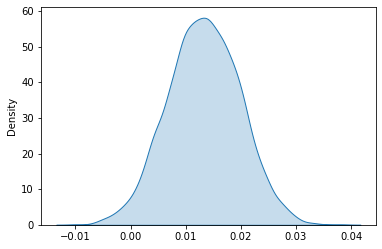

In [7]:
# Calculate posterior difference and plot it
diff = clothes_posterior - sneakers_posterior
sns.kdeplot(diff, shade=True, label="diff")
plt.show()

The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.


AxesSubplot(0.125,0.125;0.775x0.755)


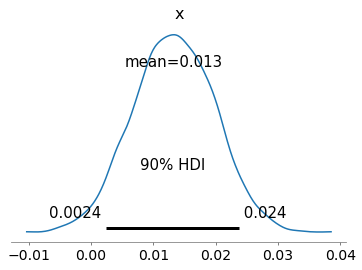

In [8]:
import pymc3 as pm
# Calculate and print 90% credible interval of posterior difference
interval =  pm.plot_posterior(diff, hdi_prob=0.9)
print(interval)

In [9]:
import arviz as az
# Calculate and print 90% credible interval of posterior difference
interval =  az.hdi(diff, hdi_prob=0.9)
print(interval)

[0.00241395 0.02378448]


In [10]:

# Calculate and print probability of clothes ad being better
clothes_better_prob = (diff>0).mean()
print(clothes_better_prob)

0.978


# How bad can it be?

You have concluded that with 98% probability, clothes ads have a higher click-through ratio than sneakers ads. This suggests rolling out the clothes campaign to a larger audience. However, there is a 2% risk that it's the sneakers ads that are actually better. If that's the case, how many clicks do we lose if we roll out the clothes campaign?

The answer to this is the expected loss: the average posterior difference between the two click-through ratios given that sneakers ads do better. To calculate it, you only need to take the entries in the posterior difference where the sneakers click-through rate is higher and compute their average.



In [12]:
# Slice diff to take only cases where it is negative
loss = diff[diff < 0] # NOT (diff<0).mean()

# Compute and print expected loss
expected_loss = loss.mean()
print(expected_loss)

-0.0023926355094159766


# Decision analysis: cost

Your journey in marketing continues. You have already calculated the posterior click rates for clothes and sneakers ads, available in your workspace as clothes_posterior and sneakers_posteriors, respectively. Your boss, however, is not interested in the distributions of click rates. They would like to know what would be the cost of rolling out an ad campaign to 10'000 users. The company's advertising partner charges $2.5 per click on a mobile device and $2 on a desktop device. Your boss is interested in the cost of the campaign for each product (clothes and sneakers) on each platform (mobile and desktop): four quantities in total.

C:\Users\88016\AppData\Local\Temp/ipykernel_32416/1394485570.py:15: DeprecationWarning: The function `forestplot` from PyMC3 is just an alias for `plot_forest` from ArviZ. Please switch to `pymc3.plot_forest` or `arviz.plot_forest`.
  pm.forestplot(ads_costs, hdi_prob=0.99, textsize=15)


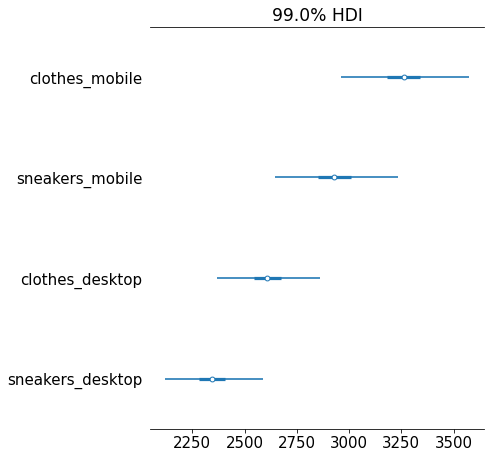

In [13]:
# Calculate distributions of the numbers of clicks for clothes and sneakers
clothes_num_clicks = clothes_posterior * 10000
sneakers_num_clicks = sneakers_posterior * 10000

# Calculate cost distributions for each product and platform
ads_costs = {
    "clothes_mobile": clothes_num_clicks * 2.5 ,
    "sneakers_mobile": sneakers_num_clicks * 2.5,
    "clothes_desktop": clothes_num_clicks * 2,
    "sneakers_desktop": sneakers_num_clicks * 2,
}


# Draw a forest plot of ads_costs
pm.forestplot(ads_costs, hdi_prob=0.99, textsize=15)
plt.show()

The ends of the whiskers mark the 99% credible interval, so there is a 1% chance the cost will fall outside of it. It's very, very unlikely, but there is a slim chance that the clothes-mobile cost will turn out lower. It's important to stay cautious when communicating possible scenarios -- that's the thing with probability, it's rarely the case that something is 'completely impossible'!

# Decision analysis: profit

In the meantime, a new company policy has been released. From now on, the goal of the marketing department is not to minimize the costs of campaigns, which was quite ineffective, but rather to maximize the profit. Can you adjust your findings accordingly, knowing that the expected revenue per click from a mobile ad is $3.4, and the one from a desktop ad is $3? To calculate the profit, you need to calculate the revenue from all clicks, then subtract the corresponding cost from it.

C:\Users\88016\AppData\Local\Temp/ipykernel_32416/1314437355.py:11: DeprecationWarning: The function `forestplot` from PyMC3 is just an alias for `plot_forest` from ArviZ. Please switch to `pymc3.plot_forest` or `arviz.plot_forest`.
  pm.forestplot(ads_profit, hdi_prob=0.99, textsize=15)


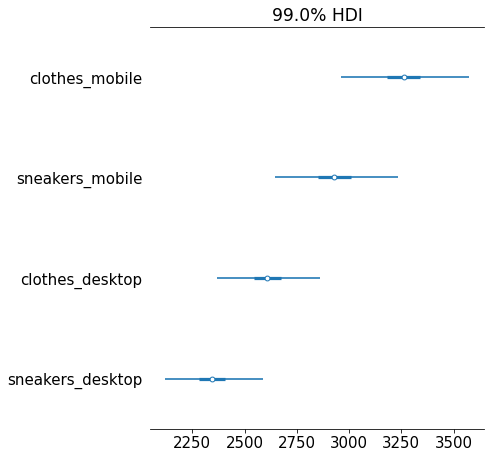

In [18]:
# Calculate profit distributions for each product and platform
ads_profit = {
    "clothes_mobile": clothes_num_clicks * 3.4 - ads_costs["clothes_mobile"],
    "sneakers_mobile": sneakers_num_clicks * 3.4 - ads_costs["sneakers_mobile"],
    "clothes_desktop": clothes_num_clicks * 3 - ads_costs["clothes_desktop"],
    "sneakers_desktop": sneakers_num_clicks * 3 - ads_costs["sneakers_desktop"],
}


# Draw a forest plot of ads_costs
pm.forestplot(ads_profit, hdi_prob=0.99, textsize=15)
plt.show()

# Defining a Bayesian regression model

You have been tasked with building a predictive model to forecast the daily number of clicks based on the numbers of clothes and sneakers ads displayed to the users. You decide to use Bayesian linear regression. You've defined your model as follows:

<center><img src="images/03.01.png"  style="width: 400px, height: 300px;"/></center>

- The intercept, or β0, would be the predicted number of clicks if both AdsShown variables are zero, and the prior is quite strongly confident that it's zero, that is: no clicks.
-  Both β1 and β2 can be interpreted as click rates. After all, each of them denotes the number of additional clicks generated from displaying a particular ad. And indeed, β2 is larger than β1, indicating that you expect a higher click rate of sneakers ads.
- you are more certain about the sneakers ad's impact, which is reflected in the corresponding prior's standard deviation. It is smaller than the one for clothes, which makes the normal prior narrower and taller, indicating less uncertainty!

# Analyzing regression parameters

Your linear regression model has four parameters: the intercept, the impact of clothes ads, the impact of sneakers ads, and the variance. The draws from their respective posterior distributions have been sampled for you and are available as intercept_draws, clothes_draws, sneakers_draws, and sd_draws, respectively.

Before you make predictions with your model, it's a good practice to analyze the posterior draws visually. In this exercise, you will first take a look at the descriptive statistics for each parameter's draws, and then you will visualize the posterior distribution for one of them

In [19]:
import numpy as np
n_samples = 2000
intercept_draws = np.random.normal(loc=1.280420110434809, scale=0.9036194738571688, size=n_samples)
clothes_draws = np.random.normal(loc=0.10459390077643661, scale=0.030274282710656134, size=n_samples)
sneakers_draws = np.random.normal(loc=0.10359376097356286, scale=0.0315881101082422, size=n_samples)
sd_draws = np.random.normal(loc=2.651661160056662, scale=0.1594512823484793, size=n_samples)

       intercept_draws  clothes_draws  sneakers_draws     sd_draws
count      2000.000000    2000.000000     2000.000000  2000.000000
mean          1.271691       0.104431        0.104234     2.655083
std           0.938534       0.031247        0.031013     0.162616
min          -1.759386       0.009002        0.012192     2.025707
25%           0.645326       0.082077        0.082447     2.549010
50%           1.260562       0.104452        0.103439     2.653110
75%           1.928489       0.125885        0.125579     2.768881
max           4.786040       0.204774        0.214312     3.145542


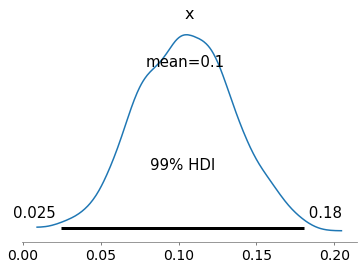

In [20]:
# Collect parameter draws in a DataFrame
posterior_draws_df = pd.DataFrame({
    "intercept_draws": intercept_draws,
    "clothes_draws": clothes_draws,
  	"sneakers_draws": sneakers_draws,
    "sd_draws": sd_draws,
})


# Describe parameter posteriors
draws_stats = posterior_draws_df.describe()
print(draws_stats)


# Plot clothes parameter posterior
pm.plot_posterior(clothes_draws, hdi_prob=0.99)
plt.show()

# Predictive distribution

Let's now use the linear regression model to make predictions. How many clicks can we expect if we decide to show 10 clothes ads and 10 sneaker ads? To find out, you will have to draw from the predictive distribution: a normal distribution with the mean defined by the linear regression formula and standard deviation estimated by the model.

First, you will summarize each parameter's posterior with its mean. Then, you will calculate the mean of the predictive distribution according to the regression equation. Next, you will draw a sample from the predictive distribution and finally, you will plot its density.

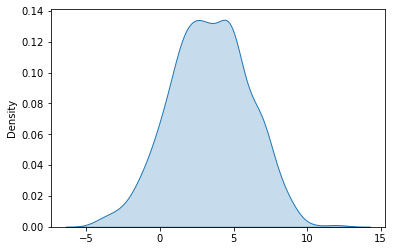

In [22]:

# Aggregate posteriors of the parameters to point estimates
intercept_coef = np.mean(intercept_draws)
sneakers_coef = np.mean(sneakers_draws)
clothes_coef = np.mean(clothes_draws)
sd_coef = np.mean(sd_draws)


# Calculate the mean of the predictive distribution for 10 sneaker and 10 clothes ads
pred_mean = intercept_coef + 10 * sneakers_coef + 10 * clothes_coef


# Sample 1000 draws from the predictive distribution
pred_draws = np.random.normal(loc=pred_mean, scale=sd_coef, size=1000)


# Plot the density of the predictive distribution
pm.plot_posterior(pred_draws, hdi_prob=0.99)
plt.show()